Load and split dataset

In [1]:
from utils.datasets import load_dataset
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

data, labels = load_dataset()
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42)

Test Linear model

In [2]:
from utils.models import load_linear, fit_linear, evaluate_linear_accuracy, evaluate_linear_f1

linear_accuracys = []
lienar_f1s = []
for i in range(5):
    linear = load_linear()
    linear = fit_linear(linear, X_train, y_train)
    linear_accuracy = evaluate_linear_accuracy(linear, X_test, y_test)
    linear_f1 = evaluate_linear_f1(linear, X_test, y_test)
    linear_accuracys.append(linear_accuracy)
    lienar_f1s.append(linear_f1)

print (f"Linear - Acc: {linear_accuracy}. F1: {linear_f1}")

Linear - Acc: 0.9776666666666667. F1: 0.9876452148257422


Test Quadratic model

In [3]:
from utils.models import load_qda, fit_qda, evaluate_qda_accuracy, evaluate_qda_f1

qda = load_qda()
qda = fit_qda(qda, X_train, y_train)
qda_accuracy = evaluate_qda_accuracy(qda, X_test, y_test)
qda_f1 = evaluate_qda_accuracy(qda, X_test, y_test)

print (f"QDA - Acc: {qda_accuracy}. F1: {qda_f1}")

QDA - Acc: 0.9473333333333334. F1: 0.9473333333333334


Test KNN model

KNN: 0.9957478276945831
KNN: 0.9944465012958164
KNN: 0.9966752862947913
KNN: 0.9957478276945831
KNN: 0.9944465012958164
KNN: 0.9966752862947913
KNN: 0.9957478276945831
KNN: 0.9944465012958164
KNN: 0.9966752862947913
KNN: 0.9957478276945831
KNN: 0.9944465012958164
KNN: 0.9966752862947913
KNN: 0.9957478276945831
KNN: 0.9944465012958164
KNN: 0.9966752862947913


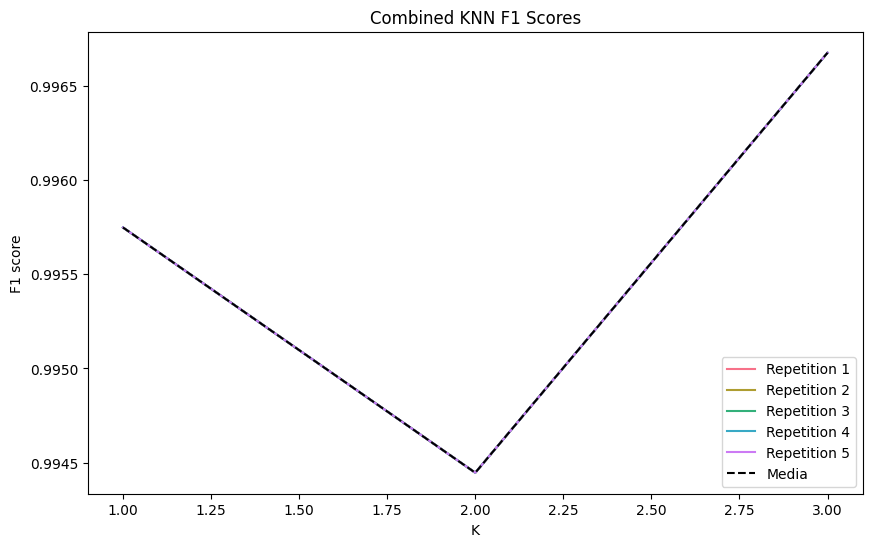

In [6]:
from utils.models import load_knn, fit_knn, evaluate_knn_f1
from utils.visualization import plot_KNN_scores_combined
import matplotlib.pyplot as plt
import random

knn_cross_values_list = []  # Lista de valores de F1 para cada repetición
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=i*3)
    
    knn_cross_values = []
    for j in range(3):
        knn = load_knn(n_neighbors=j + 1)
        knn = fit_knn(knn, X_train, y_train)
        knn_cross_val = evaluate_knn_f1(knn, X_test, y_test)
        knn_cross_values.append(knn_cross_val)
        print(f"KNN: {knn_cross_val}")
    
    knn_cross_values_list.append(knn_cross_values)

# Ahora puedes trazar la gráfica con las líneas de cada repetición y la media
plot_KNN_scores_combined(knn_cross_values_list)

Test MLP model

MLP - Acc: 0.9033333333333333. F1: 0.9492119089316988
MLP - Acc: 0.9853333333333333. F1: 0.9918608953015169
MLP - Acc: 0.9866666666666667. F1: 0.9926090169992609
MLP - Acc: 0.9856666666666667. F1: 0.9920590951061865
MLP - Acc: 0.9033333333333333. F1: 0.9492119089316988


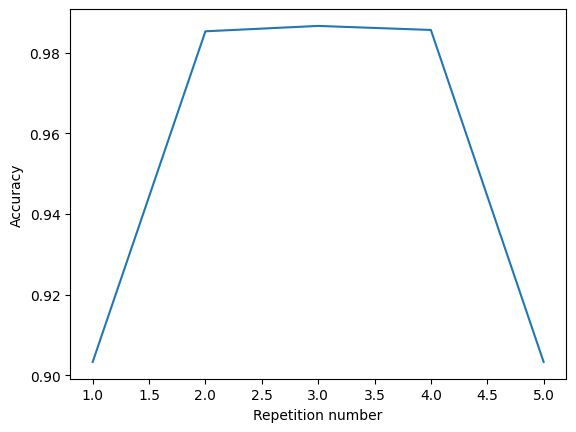

In [ ]:
from utils.models import load_mlp, fit_mlp, evaluate_mlp_accuracy, evaluate_mlp_f1
from utils.visualization import plot_MLP

mlp_accuracys = []
for i in range(5):
    mlp = load_mlp(hidden_layer_sizes=(i+1,), activation="relu")
    mlp = fit_mlp(mlp, X_train, y_train)
    mlp_accuracy = evaluate_mlp_accuracy(mlp, X_test, y_test)
    mlp_accuracys.append(mlp_accuracy)
    mlp_f1 = evaluate_mlp_f1(mlp, X_test, y_test)
    print (f"MLP - Acc: {mlp_accuracy}. F1: {mlp_f1}")
plot_MLP(mlp_accuracys)

Test SVM model

In [ ]:
from utils.models import load_svm, fit_svm, evaluate_svm_accuracy, evaluate_svm_f1

svm = load_svm()
svm = fit_svm(svm, X_train, y_train)
svm_accuracy = evaluate_svm_accuracy(svm, X_test, y_test)
svm_f1 = evaluate_svm_f1(svm, X_test, y_test)

print (f"SVM - Acc: {svm_accuracy}. F1: {svm_f1}")

SVM - Acc: 0.9896666666666667. F1: 0.9942857142857143


Test K-Means model `FALTA PROBAR`

In [ ]:
from utils.models import load_kmeans, fit_kmeans, evaluate_kmeans_accuracy, evaluate_kmeans_f1

kmeans = load_kmeans(n_clusters=3)
kmeans = fit_kmeans(kmeans, X_train)
kmeans_accuracy = evaluate_kmeans_accuracy(kmeans, X_test, y_test)
# kmeans_f1 = evaluate_kmeans_f1(kmeans, X_test, y_test)

print(f"KMeans - Acc: {kmeans_accuracy}.")

KMeans - Acc: 0.15066666666666667.
